# EDA on preprocessed features

Inspects the post-feature-engineering cached dataframe (output of stage [3/5] in `train.py`) to confirm:

1. Sanity — wind/dp_tmp columns dropped, `score_lag52` + `anom_tmp_range` present.
2. `score_lag52` — distribution + per-horizon correlation; comparison vs `score_lag1`/`score_lag8`.
3. `anom_tmp_range` — distribution (~N(0,1) by construction), residual correlation with raw `tmp_range_mean_lag0`.
4. Transform inspection — distribution of `_mean_lag0` for `prec`, `tmp_max`, `wb_tmp` (verifies log1p/winsor/rank-normalization).
5. Calendar drift recheck — KS distance for retained meteo features between train-fold and val-fold weeks.

Re-run `python code/train.py` first if no cache file exists yet.

In [ ]:
# --- Setup + sanity check ----------------------------------------------
import sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

sys.path.insert(0, str(Path('..') / 'code'))
from cache import cache_path, feature_cache_key

key = feature_cache_key()
p = cache_path('train_features', key)
print(f'cache key  : {key}')
print(f'cache path : {p}')
assert p.is_file(), f'No cache at {p}. Run code/train.py first to populate.'

with open(p, 'rb') as f:
    cached = pickle.load(f)
train_split = cached['train_split']
val_split   = cached['val_split']
all_feature_cols = cached['all_feature_cols']

wind_cols   = [c for c in train_split.columns if c.startswith(('wind', 'dp_tmp'))]
expect_cols = ['score_lag52', 'anom_tmp_range']
missing_new = [c for c in expect_cols if c not in train_split.columns]

print(f'\ntrain_split shape : {train_split.shape}')
print(f'val_split   shape : {val_split.shape}')
print(f'feature cols (#)  : {len(all_feature_cols)}  (previous baseline: 541 — expect ~395)')
print(f'wind/dp_tmp leftovers : {wind_cols if wind_cols else "none ✅"}')
print(f'missing new features  : {missing_new if missing_new else "none ✅"}')
print(f'\nscore_lag* columns present: {[c for c in all_feature_cols if c.startswith("score_lag")]}')
print(f'anom_* columns present    : {[c for c in all_feature_cols if c.startswith("anom_")]}')

Pearson r(score_lag*, target_w{h}):
         score_lag1  score_lag2  score_lag4  score_lag8  score_lag52
horizon                                                             
1             0.940       0.910       0.854       0.752        0.266
2             0.910       0.882       0.827       0.728        0.261
3             0.881       0.853       0.801       0.706        0.256
4             0.853       0.826       0.775       0.685        0.250
5             0.826       0.800       0.751       0.665        0.245


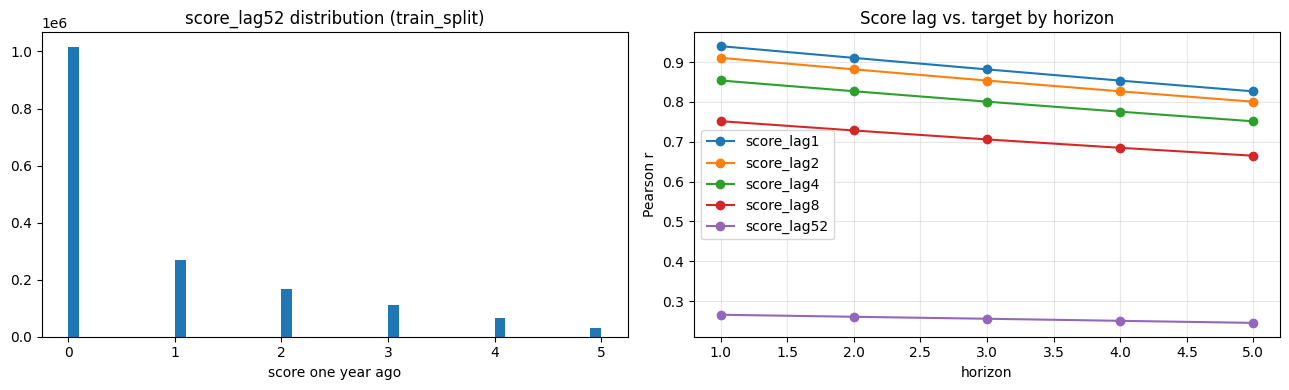

In [3]:
# --- score_lag52 ---------------------------------------------------------
# Hypothesis: lag-52 captures same-week-prior-year persistence that lags 1/2/4/8 miss.
# If it's working, correlation with target should be positive and roughly
# competitive with score_lag8 at longer horizons.
lag_cols = ['score_lag1', 'score_lag2', 'score_lag4', 'score_lag8', 'score_lag52']
horizons = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_split['score_lag52'].values, bins=50)
axes[0].set_title('score_lag52 distribution (train_split)')
axes[0].set_xlabel('score one year ago')

corrs = {h: [] for h in horizons}
for h in horizons:
    y = train_split[f'target_w{h}']
    for c in lag_cols:
        corrs[h].append(np.corrcoef(train_split[c], y)[0, 1])
corr_df = pd.DataFrame(corrs, index=lag_cols).T
corr_df.index.name = 'horizon'
print('Pearson r(score_lag*, target_w{h}):')
print(corr_df.round(3))

corr_df.plot(ax=axes[1], marker='o')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('Pearson r')
axes[1].set_title('Score lag vs. target by horizon')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

horizon w1: r(anom_tmp_range, target) = +0.205   r(tmp_range_mean_lag0, target) = +0.307
horizon w5: r(anom_tmp_range, target) = +0.208   r(tmp_range_mean_lag0, target) = +0.309

r(anom_tmp_range, tmp_range_mean_lag0) = +0.570  (low → anomaly carries info beyond the raw value)


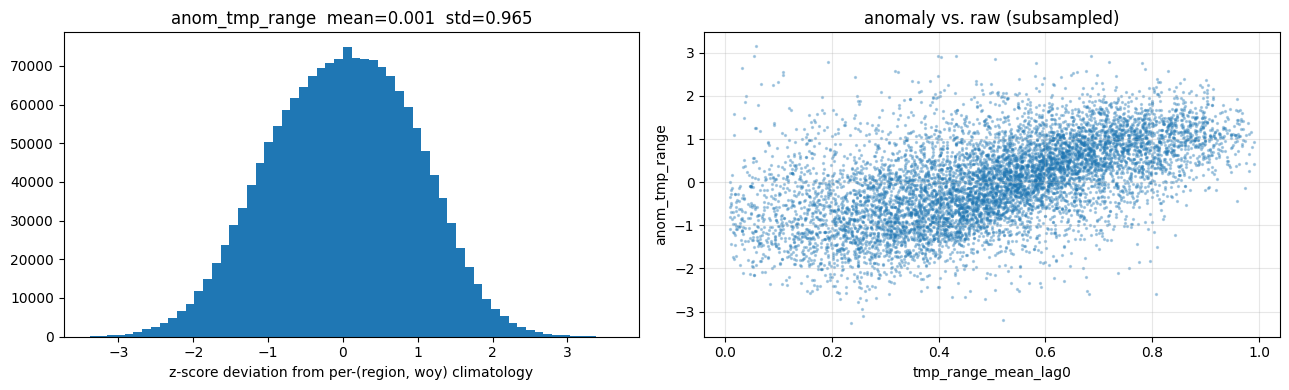

In [4]:
# --- anom_tmp_range ------------------------------------------------------
# Hypothesis: anomaly should be ~N(0,1) by construction and carry signal that's
# at least partly orthogonal to the raw tmp_range_mean_lag0.
col_anom = 'anom_tmp_range'
col_raw  = 'tmp_range_mean_lag0'
assert col_anom in train_split.columns, f'{col_anom} missing'
assert col_raw  in train_split.columns, f'{col_raw} missing'

x_anom = train_split[col_anom].values
x_raw  = train_split[col_raw].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(x_anom, bins=60)
axes[0].set_title(f'{col_anom}  mean={x_anom.mean():.3f}  std={x_anom.std():.3f}')
axes[0].set_xlabel('z-score deviation from per-(region, woy) climatology')

for h in [1, 5]:
    y = train_split[f'target_w{h}'].values
    r_anom = np.corrcoef(x_anom, y)[0, 1]
    r_raw  = np.corrcoef(x_raw,  y)[0, 1]
    print(f'horizon w{h}: r({col_anom}, target) = {r_anom:+.3f}   r({col_raw}, target) = {r_raw:+.3f}')
r_pair = np.corrcoef(x_anom, x_raw)[0, 1]
print(f'\nr({col_anom}, {col_raw}) = {r_pair:+.3f}  (low → anomaly carries info beyond the raw value)')

axes[1].scatter(x_raw[::200], x_anom[::200], s=2, alpha=0.3)
axes[1].set_xlabel(col_raw)
axes[1].set_ylabel(col_anom)
axes[1].set_title('anomaly vs. raw (subsampled)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

USE_RANK_NORMALIZATION = True
RANK_NORMALIZE_FEATURES = ['humidity', 'wb_tmp', 'tmp_range']


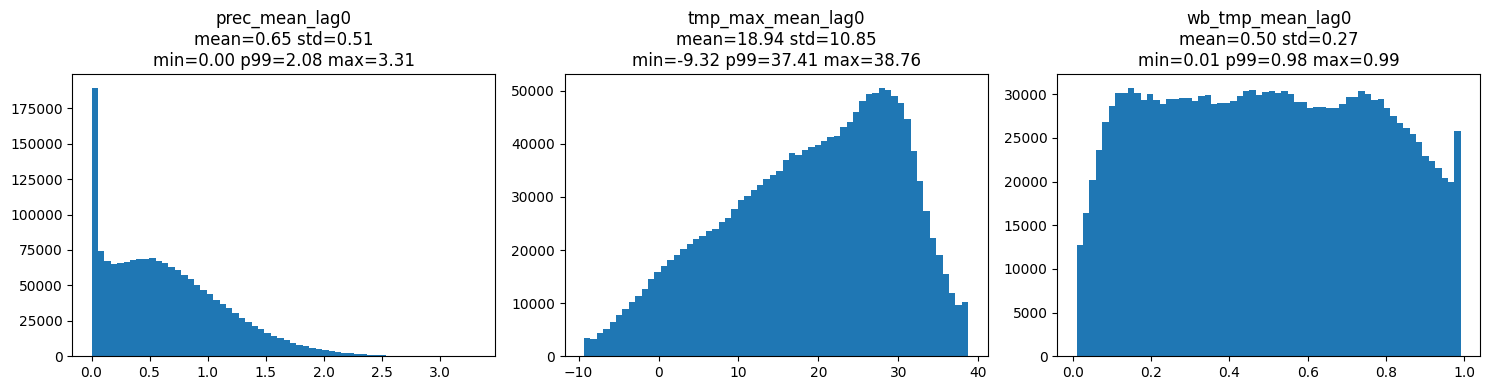

In [5]:
# --- Transform inspection ------------------------------------------------
# Verifies that preprocessing landed as intended:
#   prec_mean_lag0  — log1p applied (bounded ~ log(1+210) ≈ 5.3, right-tail tame)
#   tmp_max_mean_lag0 — winsorized to ~[p1, p99]
#   wb_tmp_mean_lag0 — rank-normalized to [0, 1] if USE_RANK_NORMALIZATION=True
from config import USE_RANK_NORMALIZATION, RANK_NORMALIZE_FEATURES
print(f'USE_RANK_NORMALIZATION = {USE_RANK_NORMALIZATION}')
print(f'RANK_NORMALIZE_FEATURES = {RANK_NORMALIZE_FEATURES}')

cols = ['prec_mean_lag0', 'tmp_max_mean_lag0', 'wb_tmp_mean_lag0']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, cols):
    v = train_split[c].values
    ax.hist(v, bins=60)
    ax.set_title(f'{c}\nmean={v.mean():.2f} std={v.std():.2f}\n'
                 f'min={v.min():.2f} p99={np.quantile(v, 0.99):.2f} max={v.max():.2f}')
plt.tight_layout()
plt.show()

            feature  ks_dist  train_mean  val_mean  mean_delta
  tmp_min_mean_lag0    0.319       7.509 14.472000       6.963
      tmp_mean_lag0    0.319      12.941 19.740000       6.799
 surf_tmp_mean_lag0    0.318      13.064 19.992001       6.928
 humidity_mean_lag0    0.314       0.495  0.686000       0.191
  tmp_max_mean_lag0    0.304      18.900 25.485001       6.585
   wb_tmp_mean_lag0    0.302       0.495  0.680000       0.185
     prec_mean_lag0    0.148       0.647  0.831000       0.185
tmp_range_mean_lag0    0.081       0.503  0.476000      -0.027
 surf_pre_mean_lag0    0.012       9.789  9.793000       0.004


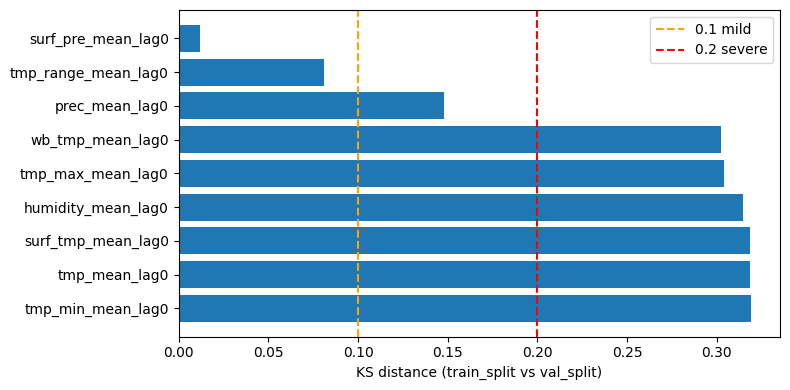

In [6]:
# --- Calendar drift recheck ---------------------------------------------
# Compare distributions between the train-fold and val-fold halves. KS
# distance > 0.1 usually flags meaningful drift; > 0.2 was the original
# train→test gap that hurt Kaggle. After feature pruning the worst-drifted
# columns should still be visible — we just want to confirm we haven't
# accidentally amplified anything.
retained_meteo = ['humidity', 'tmp', 'tmp_range', 'tmp_max', 'tmp_min',
                  'surf_tmp', 'surf_pre', 'wb_tmp', 'prec']
rows = []
for base in retained_meteo:
    col = f'{base}_mean_lag0'
    if col not in train_split.columns:
        continue
    tr = train_split[col].sample(min(50_000, len(train_split)), random_state=0).values
    va = val_split[col].sample(min(50_000, len(val_split)),   random_state=0).values
    ks_stat, _ = ks_2samp(tr, va)
    rows.append({
        'feature': col,
        'ks_dist': ks_stat,
        'train_mean': tr.mean(),
        'val_mean':   va.mean(),
        'mean_delta': va.mean() - tr.mean(),
    })
ks_df = pd.DataFrame(rows).sort_values('ks_dist', ascending=False)
print(ks_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ks_df['feature'], ks_df['ks_dist'])
ax.set_xlabel('KS distance (train_split vs val_split)')
ax.axvline(0.1, color='orange', ls='--', label='0.1 mild')
ax.axvline(0.2, color='red',    ls='--', label='0.2 severe')
ax.legend()
plt.tight_layout()
plt.show()